<a href="https://colab.research.google.com/github/gainirajkumar39-python/ml-training-internship/blob/main/%E2%80%9CHealthcare_Cost_Prediction_%26_Risk_Classification_using_Machine_Learning%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA UNDERSTANDING

In [21]:
import pandas as pd

df = pd.read_csv("/content/MUP_INP_RY24_P04_V10_DY20_Prv.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (3156, 57)
                          Rndrng_Prvdr_Org_Name             Rndrng_Prvdr_St  \
0  10001        SOUTHEAST HEALTH MEDICAL CENTER      1108 ROSS CLARK CIRCLE   
1  10005  MARSHALL MEDICAL CENTERS SOUTH CAMPUS  2505 U S HIGHWAY 431 NORTH   
2  10006           NORTH ALABAMA MEDICAL CENTER         1701 VETERANS DRIVE   
3  10007               MIZELL MEMORIAL HOSPITAL               702 N MAIN ST   
4  10008            CRENSHAW COMMUNITY HOSPITAL         101 HOSPITAL CIRCLE   

  Rndrng_Prvdr_City  Rndrng_Prvdr_Zip5 Rndrng_Prvdr_State_Abrvtn  \
0            DOTHAN              36301                        AL   
1              BOAZ              35957                        AL   
2          FLORENCE              35630                        AL   
3               OPP              36467                        AL   
4           LUVERNE              36049                        AL   

   Rndrng_Prvdr_State_FIPS  Rndrng_Prvdr_RUCA  \
0                        1                1.0   


# Handle Missing Values

In [22]:
df = df.dropna()

# Selecting Target Column

In [23]:
target_column = "Tot_Submtd_Cvrd_Chrg"   # change based on your dataset

In [24]:
print(df.columns.tolist())

['    ', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Tot_Benes', 'Tot_Submtd_Cvrd_Chrg', 'Tot_Pymt_Amt', 'Tot_Mdcr_Pymt_Amt', 'Tot_Dschrgs', 'Tot_Cvrd_Days', 'Tot_Days', 'Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_API_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_NatInd_Cnt', 'Bene_Race_Othr_Cnt', 'Bene_Dual_Cnt', 'Bene_Ndual_Cnt', 'Bene_CC_BH_ADHD_OthCD_V1_Pct', 'Bene_CC_BH_Alcohol_Drug_V1_Pct', 'Bene_CC_BH_Tobacco_V1_Pct', 'Bene_CC_BH_Alz_NonAlzdem_V2_Pct', 'Bene_CC_BH_Anxiety_V1_Pct', 'Bene_CC_BH_Bipolar_V1_Pct', 'Bene_CC_BH_Mood_V2_Pct', 'Bene_CC_BH_Depress_V1_Pct', 'Bene_CC_BH_PD_V1_Pct', 'Bene_CC_BH_PTSD_V1_Pct', 'Bene_CC_BH_Schizo_OthPsy_V1_Pct', 'Bene_CC_PH_Asthma_V2_Pct', 'Bene_CC_PH_Afib_V2_P

# Create Classification Target

In [25]:
df["HIGH_COST"] = (df[target_column] > df[target_column].median()).astype(int)

# Split Features & Target

In [26]:
X = df.drop(columns=[target_column, "HIGH_COST"])
y_reg = df[target_column]        # regression
y_clf = df["HIGH_COST"]         # classification

# Encode Categorical Data

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Regression Model

In [29]:
from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor()
reg_model.fit(X_train, y_train_reg)

RandomForestRegressor()

# Classification Model

In [30]:
from sklearn.ensemble import RandomForestClassifier

clf_model = RandomForestClassifier()
clf_model.fit(X_train, y_train_clf)

RandomForestClassifier()

# Regression Metrics

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_reg = reg_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

MAE: 143456487.70842105
R2 Score: 0.8850915849739267


# Classification Metrics

In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_clf = clf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))

Accuracy: 0.8947368421052632
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        28
           1       0.90      0.90      0.90        29

    accuracy                           0.89        57
   macro avg       0.89      0.89      0.89        57
weighted avg       0.89      0.89      0.89        57



# . FEATURE IMPORTANCE

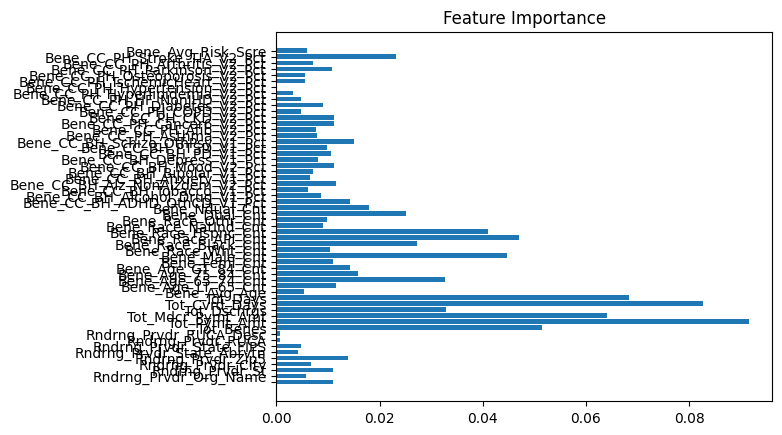

In [33]:
import matplotlib.pyplot as plt

importances = clf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

# Correlation Heatmap

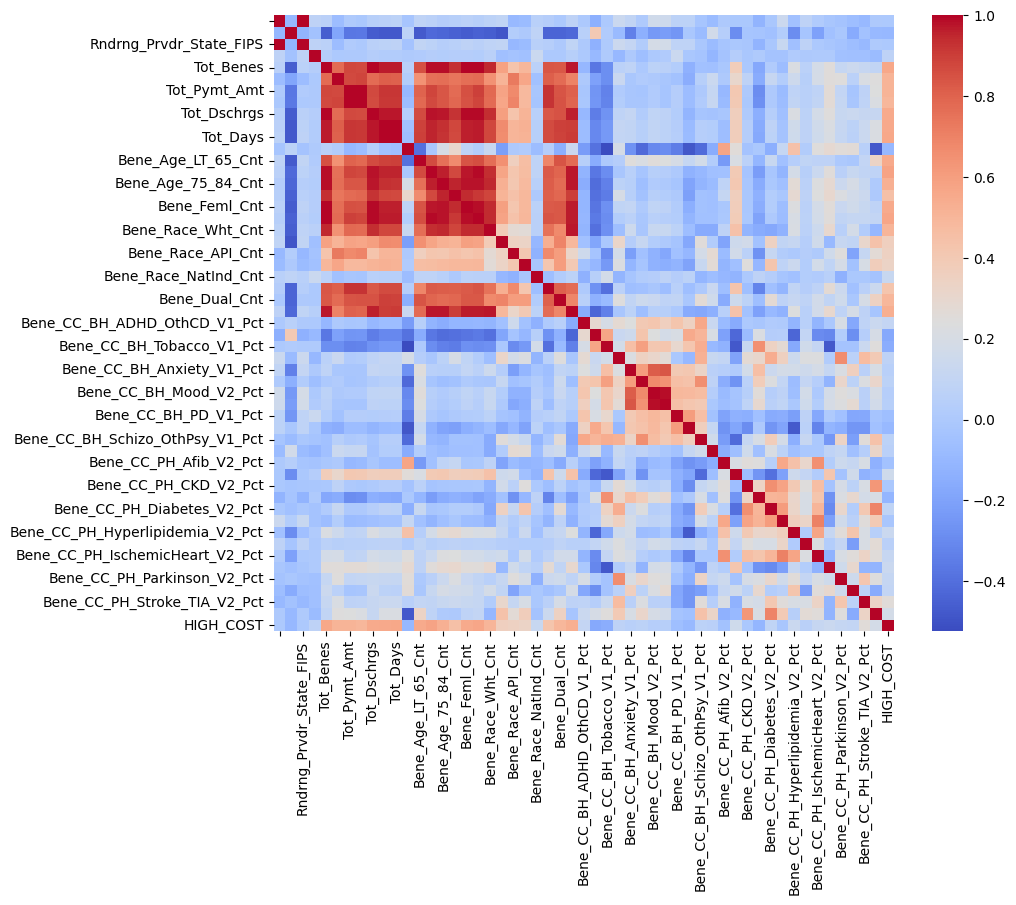

In [34]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()